# Random Forest Project

## GraphX Labs ML Concepts Portfolio

One Decision Tree is smart. A forest of them is powerful.

In this notebook, we build a Random Forest classifier to predict customer churn. Along the way, we compare it with a single Decision Tree so the improvement feels intuitive instead of magical.

## 1. Problem Statement

Customer churn happens when a customer leaves a company.

For a telecom business, churn matters because losing customers means losing recurring revenue. If the company can identify customers who are at risk before they leave, it can take action with support, offers, or better service.

Our question:

> Can we predict whether a customer is likely to churn?

## 2. Why Random Forest?

A single Decision Tree can learn useful rules, but it can also overfit. It may memorize tiny patterns in the training data and then struggle with new customers.

Random Forest solves this by building many Decision Trees and letting them vote.

Think of it like asking many experts instead of one. One expert may overreact to one detail. A group is often more stable because individual mistakes can cancel out.

Random Forest uses two clever tricks:

- bootstrap sampling: each tree sees a slightly different dataset
- feature randomness: each split sees only a subset of features

The result is a model that is usually more robust than a single tree.

## 3. Dataset Overview

Dataset: IBM Telco Customer Churn dataset.

The dataset contains telecom customer information such as contract type, tenure, monthly charges, internet services, support services, and churn status.

Target variable:

- original: `Churn`
- processed: `churn`
- `1`: customer churned
- `0`: customer stayed

This is a supervised binary classification problem.

## 4. Import Libraries

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "telco_customer_churn.csv"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "telco_customer_churn_processed.csv"
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 5. Load Dataset

In [2]:
raw_df = pd.read_csv(DATA_RAW)
raw_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Initial Data Inspection

In [3]:
print("Shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.describe(include="all").T.head(25))

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print("Missing values:")
display(raw_df.isna().sum().sort_values(ascending=False).head())
print("Duplicate rows:", raw_df.duplicated().sum())
display(raw_df["Churn"].value_counts(normalize=True).rename("proportion"))

Missing values:


customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
dtype: int64

Duplicate rows: 0


No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## 7. Exploratory Data Analysis

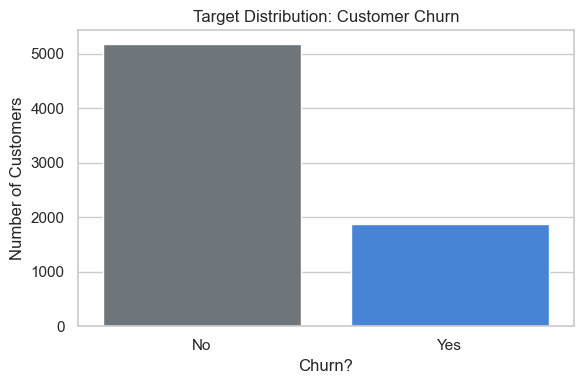

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=raw_df, x="Churn", palette=["#6C757D", "#2F80ED"])
plt.title("Target Distribution: Customer Churn")
plt.xlabel("Churn?")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

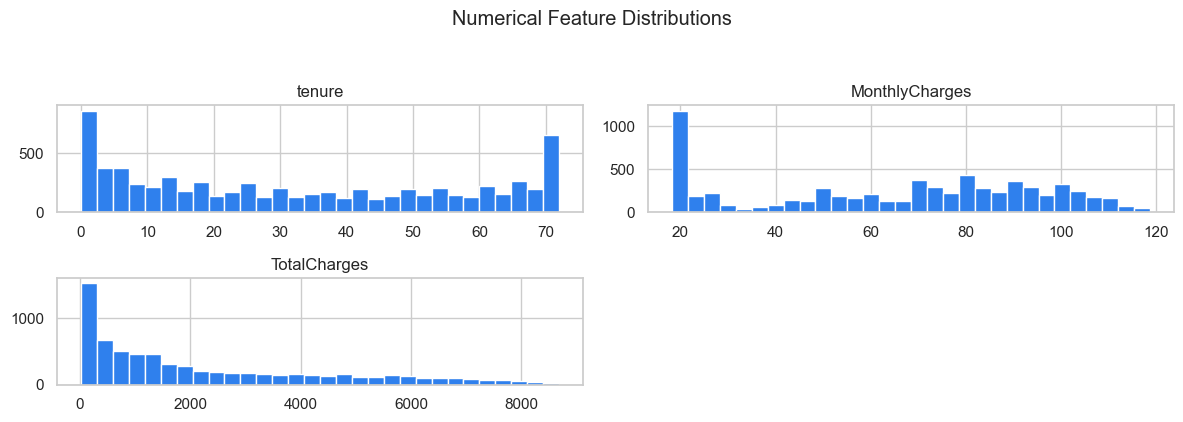

In [7]:
raw_for_plot = raw_df.copy()
raw_for_plot["TotalCharges"] = pd.to_numeric(raw_for_plot["TotalCharges"], errors="coerce")

selected_numeric = ["tenure", "MonthlyCharges", "TotalCharges"]
raw_for_plot[selected_numeric].hist(figsize=(12, 4), bins=30, color="#2F80ED", edgecolor="white")
plt.suptitle("Numerical Feature Distributions", y=1.05)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "numerical_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

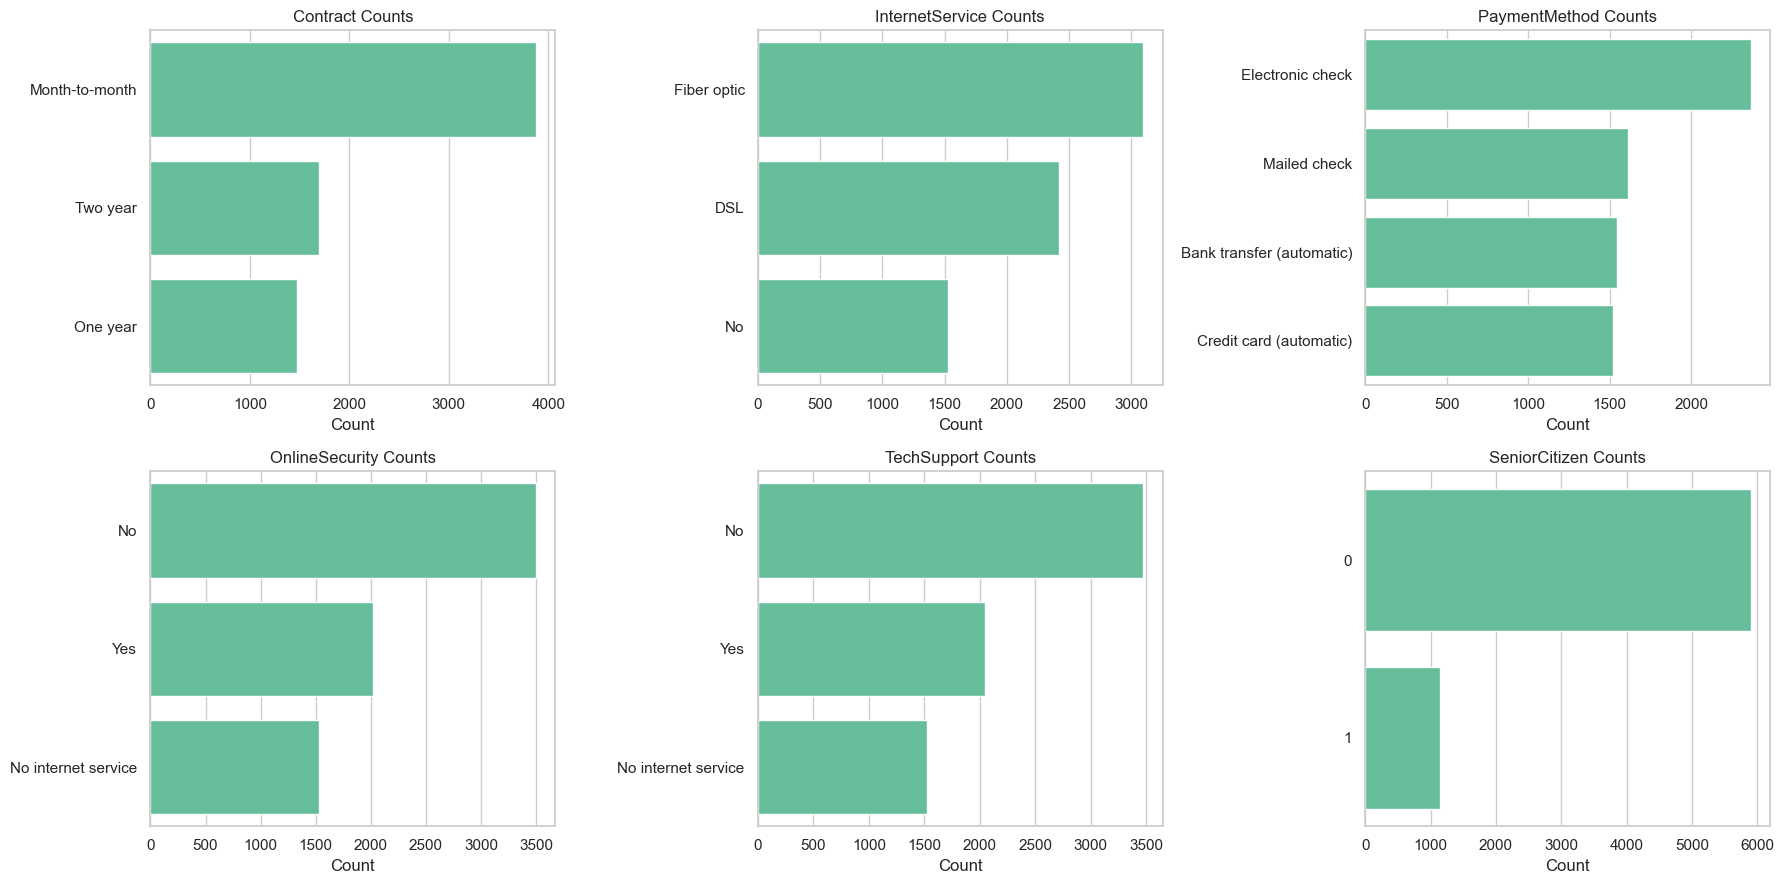

In [8]:
categorical_features = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "SeniorCitizen"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, column in zip(axes, categorical_features):
    order = raw_df[column].value_counts().index
    sns.countplot(data=raw_df, y=column, order=order, ax=ax, color="#56CC9D")
    ax.set_title(f"{column} Counts")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "categorical_feature_counts.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/7h/yh12knpx2lsgzzfbqc5zkl500000gn/T/ipykernel_54077/2614782769.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x=column, y="churn_flag", ax=ax, ci=None, color="#F2C94C")
/var/folders/7h/yh12knpx2lsgzzfbqc5zkl500000gn/T/ipykernel_54077/2614782769.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x=column, y="churn_flag", ax=ax, ci=None, color="#F2C94C")
/var/folders/7h/yh12knpx2lsgzzfbqc5zkl500000gn/T/ipykernel_54077/2614782769.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x=column, y="churn_flag", ax=ax, ci=None, color="#F2C94C")


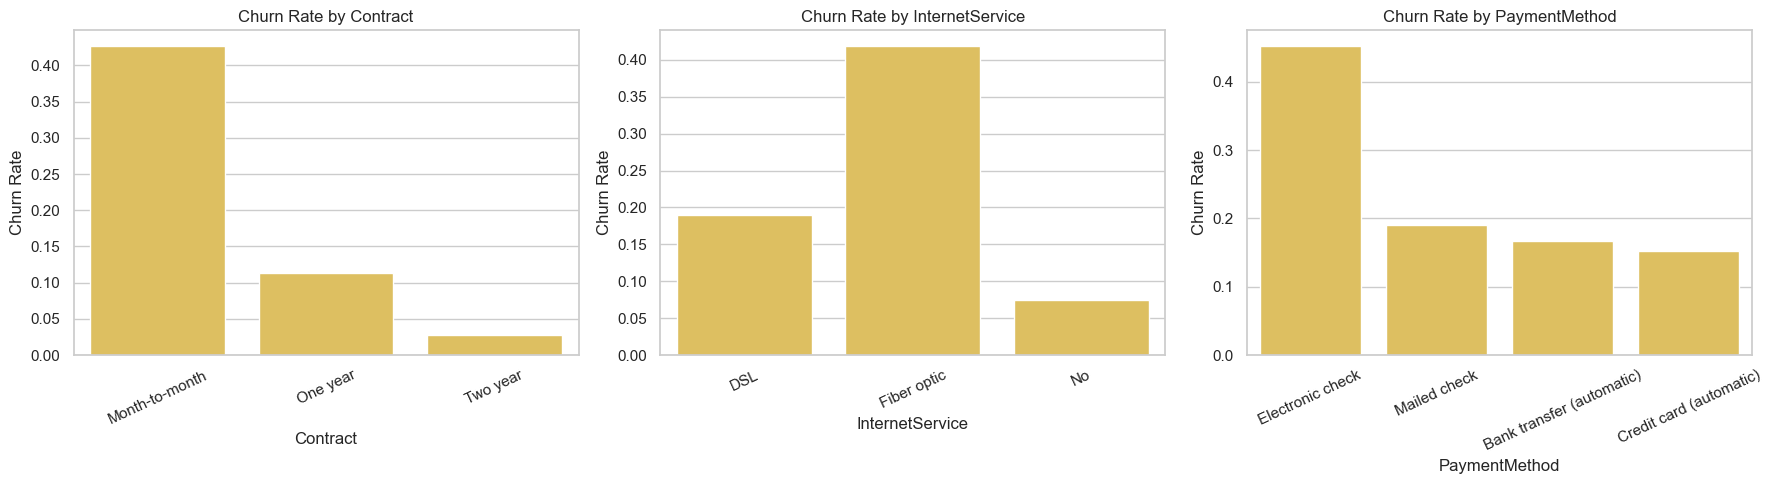

In [9]:
relationship_columns = ["Contract", "InternetService", "PaymentMethod"]
plot_df = raw_df.copy()
plot_df["churn_flag"] = (plot_df["Churn"] == "Yes").astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, relationship_columns):
    sns.barplot(data=plot_df, x=column, y="churn_flag", ax=ax, ci=None, color="#F2C94C")
    ax.set_title(f"Churn Rate by {column}")
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

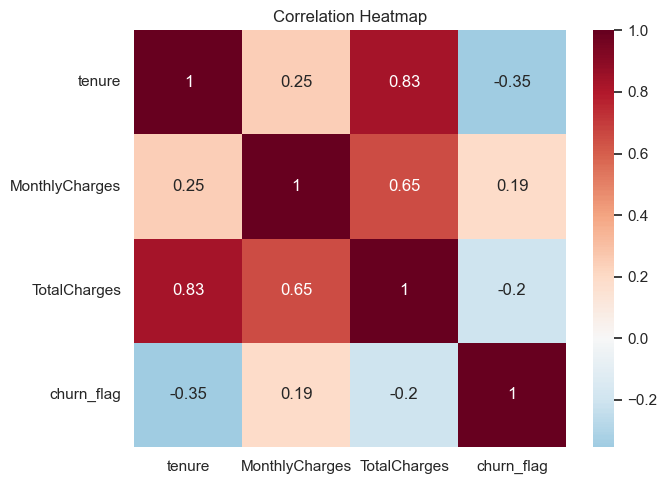

In [10]:
corr_df = raw_for_plot.copy()
corr_df["churn_flag"] = (corr_df["Churn"] == "Yes").astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_df[["tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]].corr(), annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Data Cleaning

In [11]:
df = raw_df.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")
df["totalcharges"] = df["totalcharges"].fillna(df["totalcharges"].median())
df = df.drop_duplicates().copy()
df["churn"] = df["churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerid"])

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (7043, 20)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [12]:
DATA_PROCESSED.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_PROCESSED, index=False)
print("Saved processed data to:", DATA_PROCESSED)

Saved processed data to: /Users/meenakshijayaraj/Desktop/graphx-ml-concepts-portfolio/random-forest/data/processed/telco_customer_churn_processed.csv


## 9. Feature Engineering

In [13]:
X = df.drop(columns=["churn"])
y = df["churn"]

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
print("Encoded shape:", X_encoded.shape)

Categorical columns: ['gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']
Numerical columns: ['seniorcitizen', 'tenure', 'monthlycharges', 'totalcharges']
Encoded shape: (7043, 30)


Random Forest does not require feature scaling. Like Decision Trees, it splits on thresholds instead of using distance calculations.

## 10. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4))
print("Test churn rate:", round(y_test.mean(), 4))

X_train: (5634, 30)
X_test: (1409, 30)
Train churn rate: 0.2654
Test churn rate: 0.2654


## 11. Build Baseline Decision Tree

In [15]:
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree.fit(X_train, y_train)

tree_train_pred = decision_tree.predict(X_train)
tree_test_pred = decision_tree.predict(X_test)
tree_test_prob = decision_tree.predict_proba(X_test)[:, 1]

print("Decision Tree train accuracy:", round(accuracy_score(y_train, tree_train_pred), 4))
print("Decision Tree test accuracy:", round(accuracy_score(y_test, tree_test_pred), 4))

Decision Tree train accuracy: 0.998
Decision Tree test accuracy: 0.7388


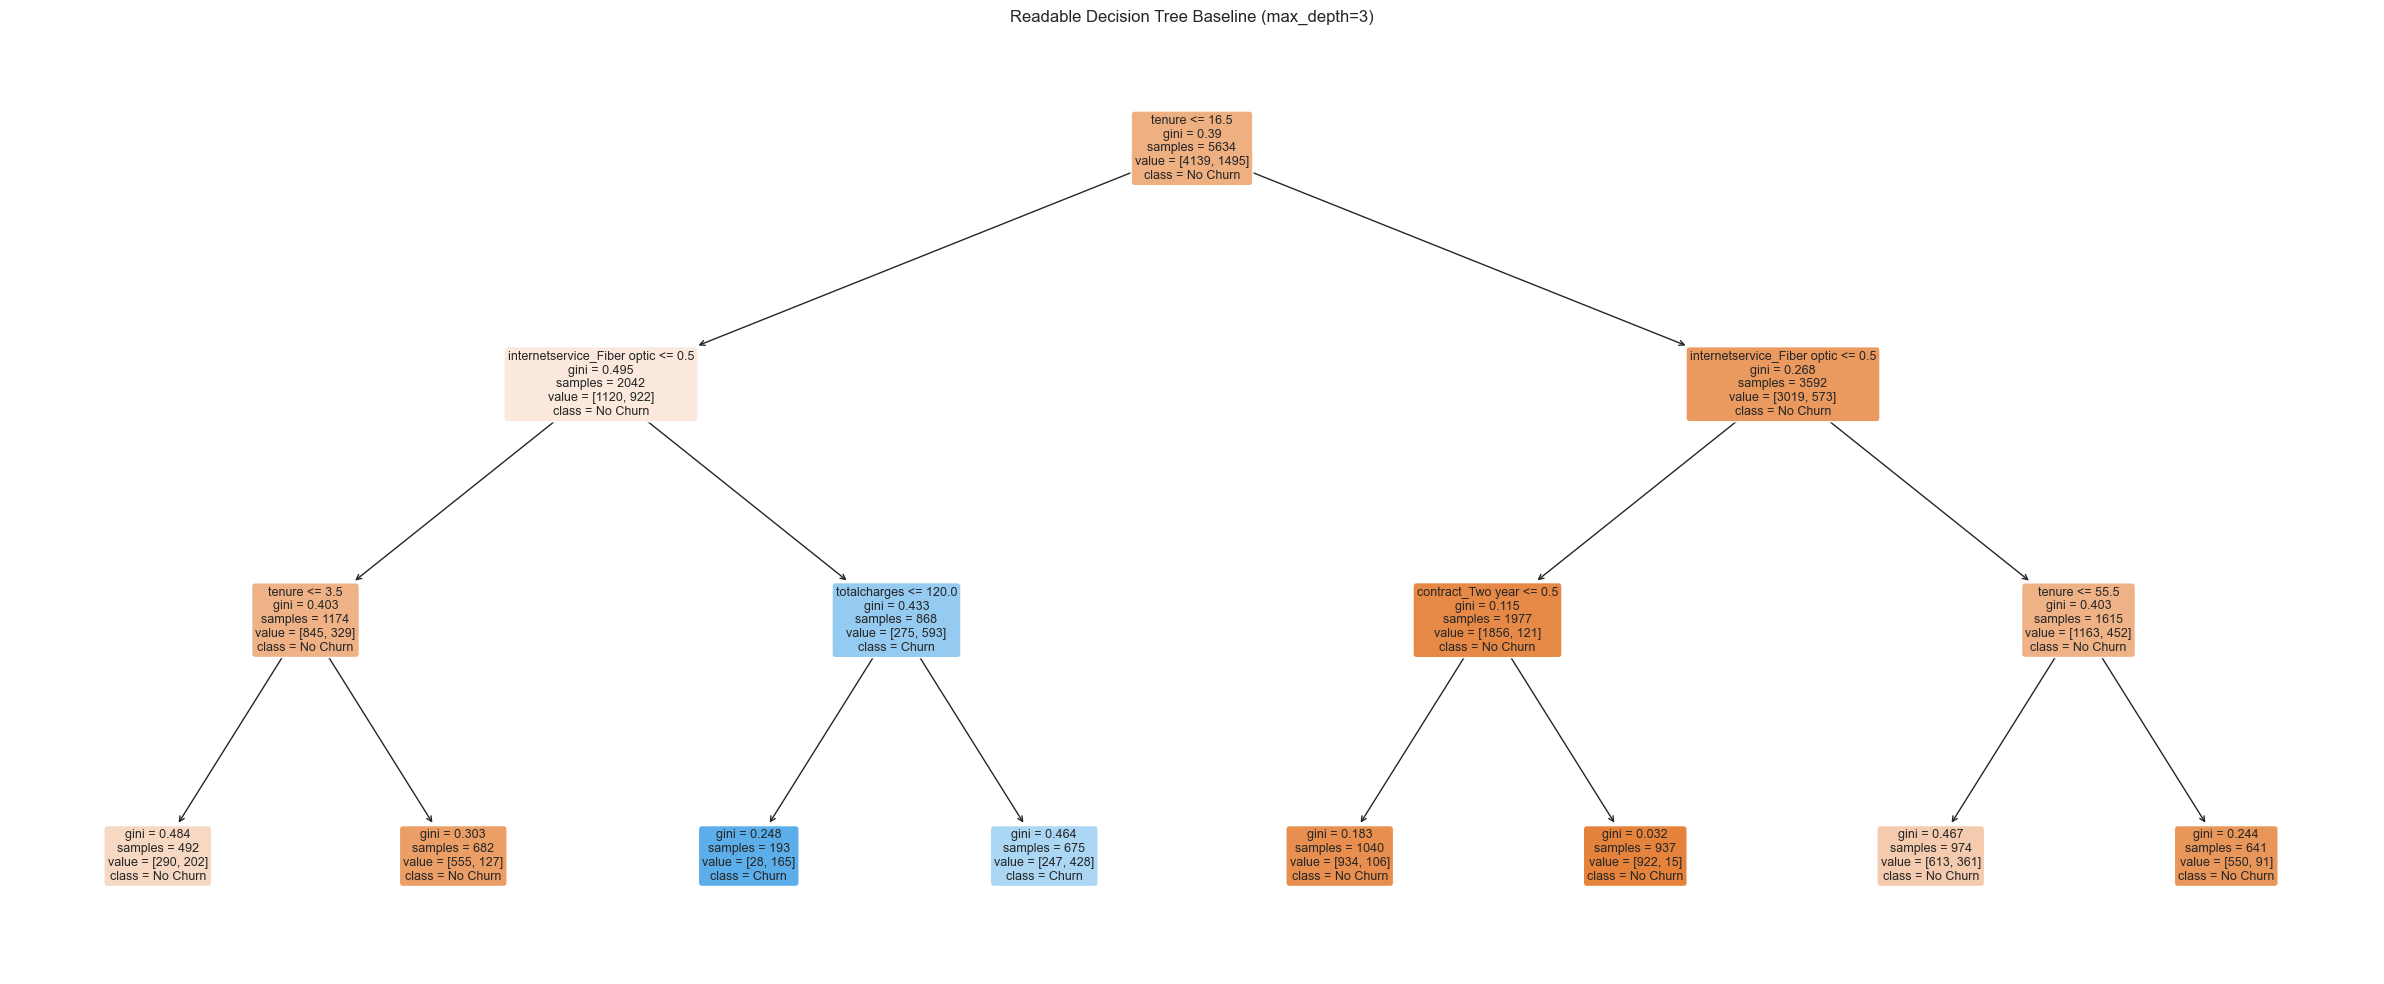

In [16]:
shallow_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=RANDOM_STATE)
shallow_tree.fit(X_train, y_train)

plt.figure(figsize=(24, 10))
plot_tree(
    shallow_tree,
    feature_names=X_encoded.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Readable Decision Tree Baseline (max_depth=3)")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Build Random Forest Model

In [17]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=1
)

random_forest.fit(X_train, y_train)
rf_train_pred = random_forest.predict(X_train)
rf_test_pred = random_forest.predict(X_test)
rf_test_prob = random_forest.predict_proba(X_test)[:, 1]

print("Random Forest train accuracy:", round(accuracy_score(y_train, rf_train_pred), 4))
print("Random Forest test accuracy:", round(accuracy_score(y_test, rf_test_pred), 4))

Random Forest train accuracy: 0.8575
Random Forest test accuracy: 0.8062


The forest uses bootstrap sampling, random feature selection, and voting. Each tree is allowed to have an opinion, but no single tree gets full control.

## 13. Model Evaluation

In [18]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_prob),
    }

results_df = pd.DataFrame([
    evaluate_model("Decision Tree", decision_tree, X_train, y_train, X_test, y_test),
    evaluate_model("Random Forest", random_forest, X_train, y_train, X_test, y_test),
])

results_df

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.998048,0.738822,0.507937,0.513369,0.510638,0.666359
1,Random Forest,0.857472,0.806246,0.674740,0.521390,0.588235,0.843486


In [19]:
print(classification_report(y_test, rf_test_pred, target_names=["No Churn", "Churn"], zero_division=0))

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



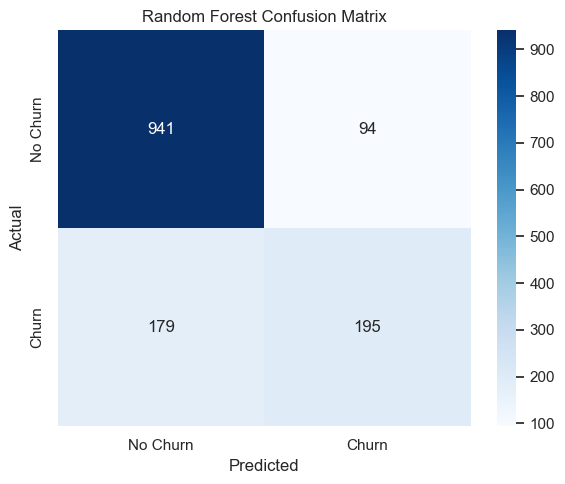

In [20]:
cm = confusion_matrix(y_test, rf_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

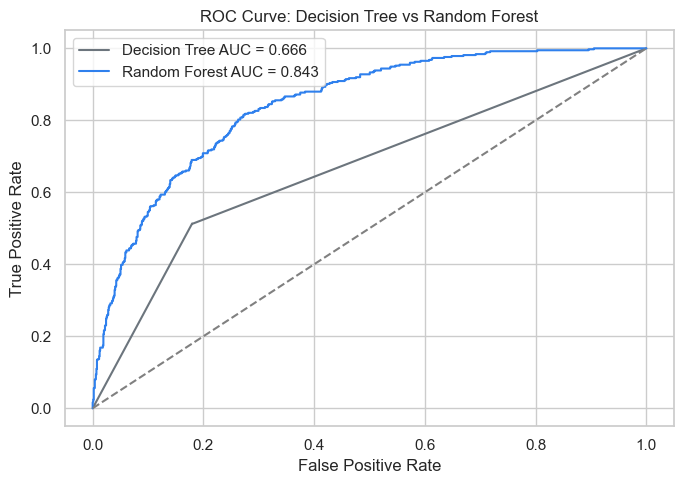

In [21]:
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_test_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(tree_fpr, tree_tpr, label=f"Decision Tree AUC = {roc_auc_score(y_test, tree_test_prob):.3f}", color="#6C757D")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest AUC = {roc_auc_score(y_test, rf_test_prob):.3f}", color="#2F80ED")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree vs Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Understanding Why Random Forest Works Better

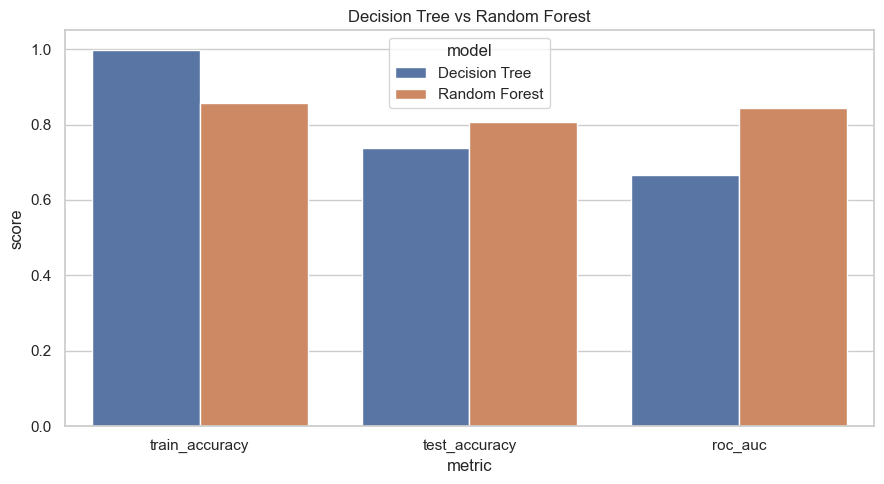

In [22]:
comparison_plot = results_df.melt(
    id_vars="model",
    value_vars=["train_accuracy", "test_accuracy", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_plot, x="metric", y="score", hue="model")
plt.title("Decision Tree vs Random Forest")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

The Decision Tree has a bigger gap between train and test performance. That is the overfitting signal.

The Random Forest is more stable because many trees vote together. One noisy tree does not get to dominate the final answer.

## 15. Feature Importance

,feature,importance
1,tenure,0.189748
3,totalcharges,0.161589
2,monthlycharges,0.113680
10,internetservice_Fiber optic,0.072915
25,contract_Two year,0.062696
28,paymentmethod_Electronic check,0.062529
13,onlinesecurity_Yes,0.036058
24,contract_One year,0.032892
19,techsupport_Yes,0.023152
26,paperlessbilling_Yes,0.021712


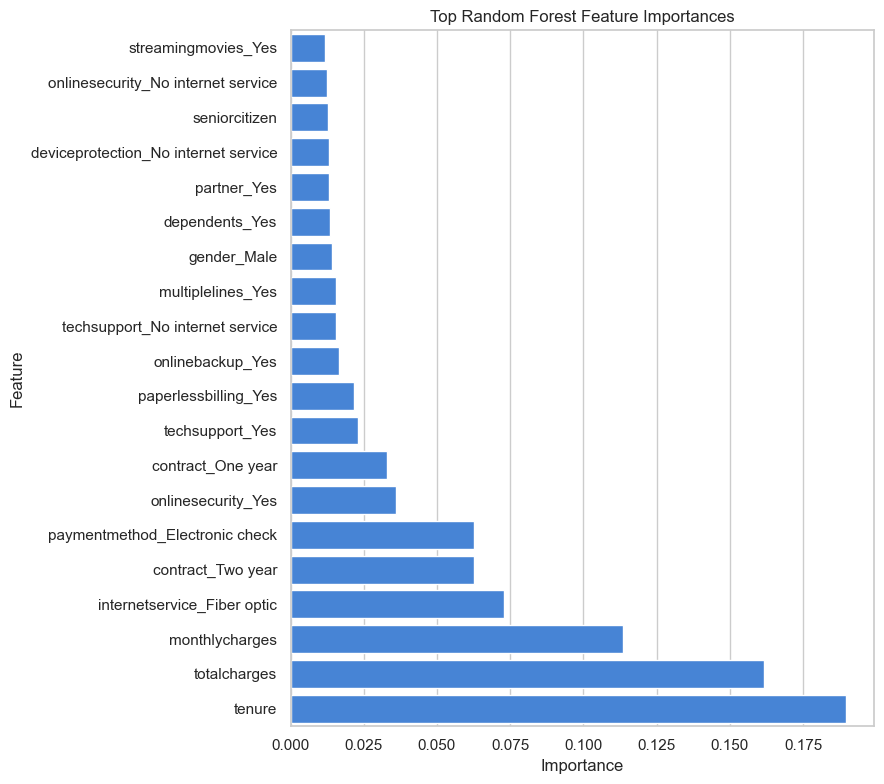

In [23]:
importance_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": random_forest.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 8))
top_importance = importance_df.head(20).sort_values("importance")
sns.barplot(data=top_importance, x="importance", y="feature", color="#2F80ED")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Hyperparameter Tuning

In [24]:
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 3],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

Best parameters: {'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.845


In [25]:
final_model = grid_search.best_estimator_
final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:, 1]

final_metrics = evaluate_model("Tuned Random Forest", final_model, X_train, y_train, X_test, y_test)
pd.DataFrame([final_metrics])

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Tuned Random Forest,0.806709,0.79418,0.670732,0.441176,0.532258,0.842891


## 17. Limitations of Random Forest

Random Forest is powerful, but not perfect.

Limitations:

- less interpretable than one Decision Tree
- larger model size
- slower training and prediction than simple models
- feature importance can be misleading
- not always as strong as tuned gradient boosting models

## 18. Final Model Summary

In [26]:
summary_results = pd.DataFrame([
    evaluate_model("Decision Tree", decision_tree, X_train, y_train, X_test, y_test),
    evaluate_model("Random Forest", random_forest, X_train, y_train, X_test, y_test),
    final_metrics,
])
summary_results

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.998048,0.738822,0.507937,0.513369,0.510638,0.666359
1,Random Forest,0.857472,0.806246,0.674740,0.521390,0.588235,0.843486
2,Tuned Random Forest,0.806709,0.794180,0.670732,0.441176,0.532258,0.842891


## 19. Key Learnings

Key lessons:

- A single Decision Tree is intuitive but fragile.
- Random Forest reduces overfitting by averaging many randomized trees.
- Bootstrap sampling gives each tree a different training view.
- Feature randomness keeps trees from becoming too similar.
- Feature importance helps interpretation, but it is not causal proof.

## 20. Interview Questions

Review these:

- What is Random Forest?
- What is bagging?
- What is bootstrap sampling?
- Why does Random Forest reduce overfitting?
- What is `n_estimators`?
- What is OOB score?
- Random Forest vs Decision Tree?
- Random Forest vs XGBoost?

See the full companion file:

`random-forest/interview_questions.md`